In [ ]:
!pip install qiskit qiskit-aer qiskit-ibm-runtime

# 1


Figure(185.453x117.056)
Statevector([0.+0.j, 1.+0.j],
            dims=(2,))


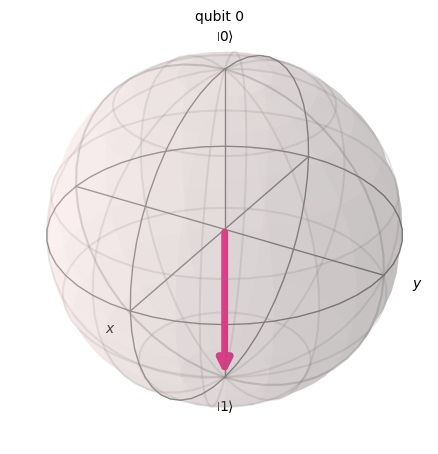

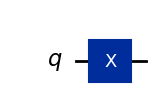

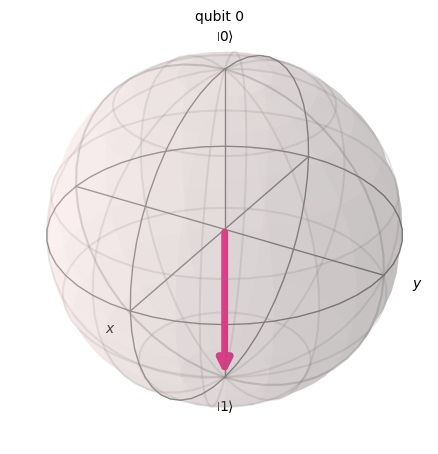

In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
import matplotlib.pyplot as plt
%matplotlib inline

qc = QuantumCircuit(1)
qc.x(0)

print(qc.draw(output='mpl'))

state = Statevector.from_instruction(qc)
print(state)

plot_bloch_multivector(state)

# 2 no need


In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
import matplotlib.pyplot as plt
from IPython.display import display
%matplotlib inline

def run_gate(gate):
    qc = QuantumCircuit(1)
    qc.h(0)
    if gate == 'y':
        qc.y(0)
    elif gate == 'z':
        qc.z(0)
    elif gate == 's':
        qc.s(0)
    elif gate == 'sdg':
        qc.sdg(0)
    elif gate == 't':
        qc.t(0)
    elif gate == 'tdg':
        qc.tdg(0)

    state = Statevector.from_instruction(qc)

    print(gate.upper())
    display(qc.draw(output='mpl'))
    print(state)

    fig = plot_bloch_multivector(state)
    display(fig)
    plt.close(fig)

Y


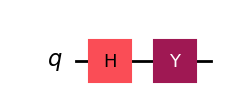

Statevector([0.-0.70710678j, 0.+0.70710678j],
            dims=(2,))


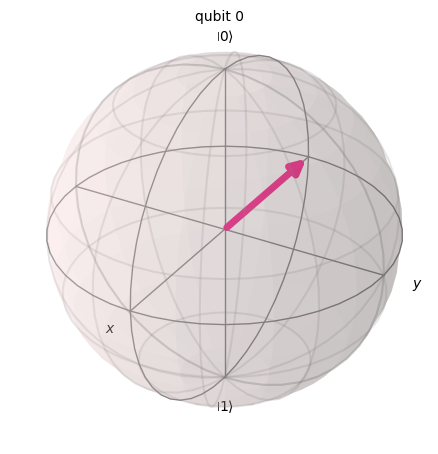

Z


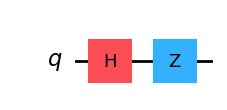

Statevector([ 0.70710678+0.j, -0.70710678+0.j],
            dims=(2,))


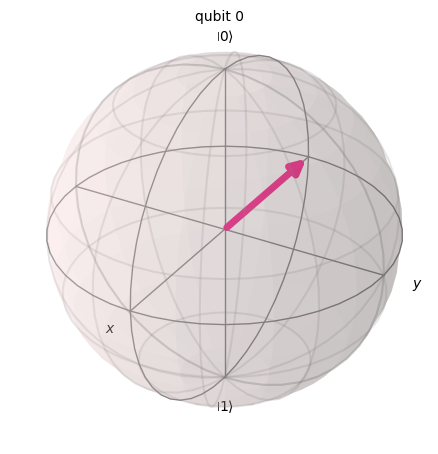

S


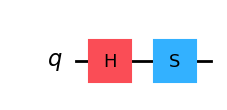

Statevector([0.70710678+0.j        , 0.        +0.70710678j],
            dims=(2,))


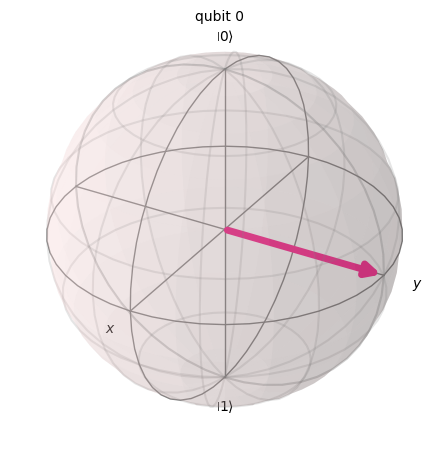

SDG


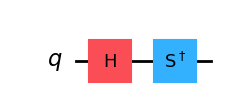

Statevector([0.70710678+0.j        , 0.        -0.70710678j],
            dims=(2,))


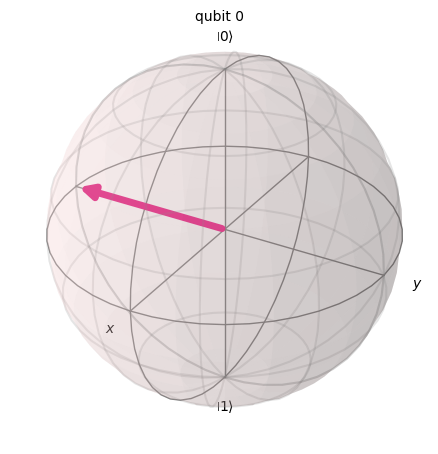

T


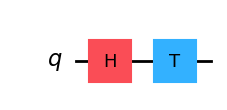

Statevector([0.70710678+0.j , 0.5       +0.5j],
            dims=(2,))


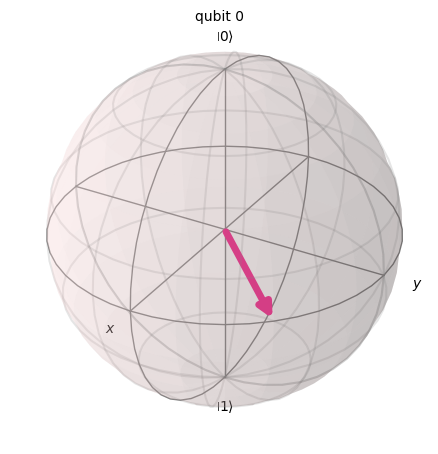

TDG


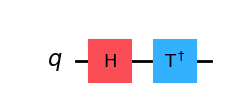

Statevector([0.70710678+0.j , 0.5       -0.5j],
            dims=(2,))


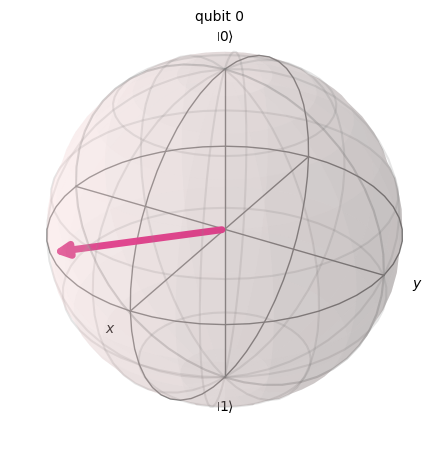

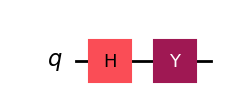

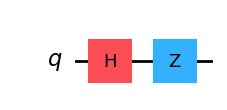

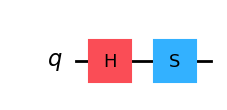

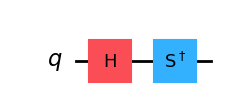

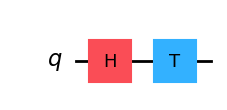

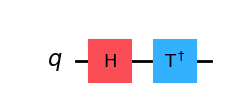

In [13]:
for g in ["y", "z", "s", "sdg", "t", "tdg"]:
    run_gate(g)

# 3


Figure(538.128x284.278)


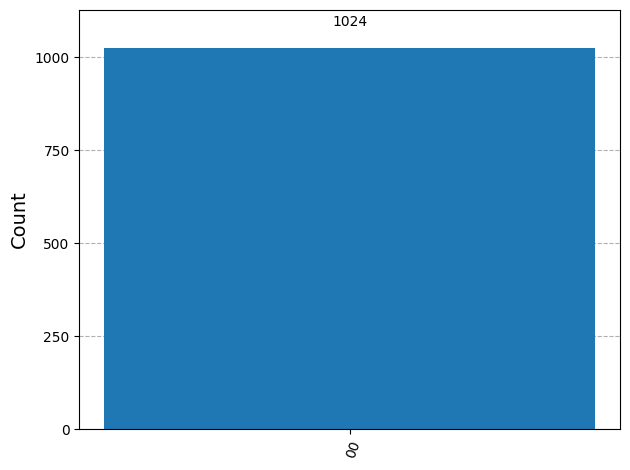

Figure(538.128x284.278)


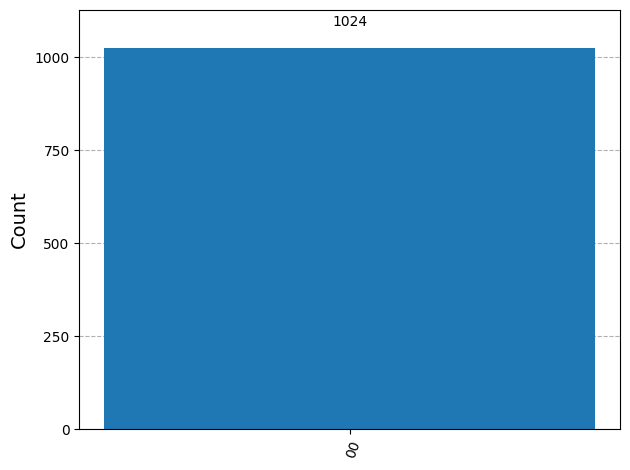

Figure(538.33x367.889)


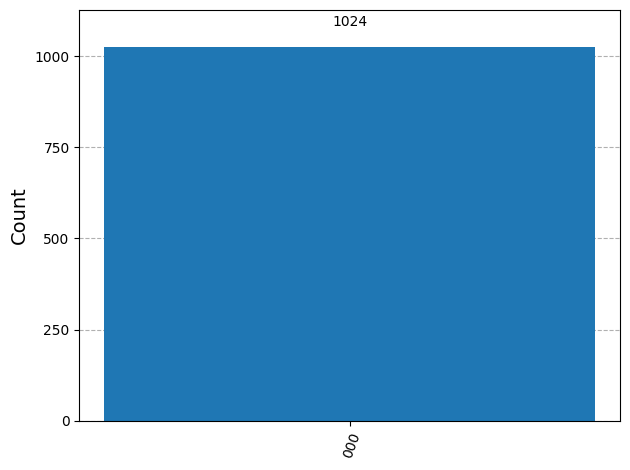

Figure(621.941x367.889)


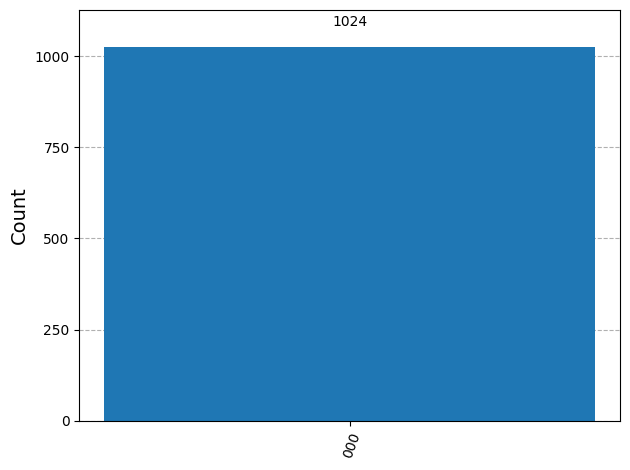

In [ ]:
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram

sampler = StatevectorSampler()

def run(qc):
    print(qc.draw("mpl"))
    job = sampler.run([qc], shots=1024)
    counts = job.result()[0].data.c.get_counts()
    display(plot_histogram(counts))

qc_a = QuantumCircuit(2, 2)
qc_a.h(1)
qc_a.cz(0, 1)
qc_a.h(1)
qc_a.measure([0, 1], [0, 1])
run(qc_a)

qc_b = QuantumCircuit(2, 2)
qc_b.h(0)
qc_b.h(1)
qc_b.cx(0, 1)
qc_b.h(0)
qc_b.h(1)
qc_b.measure([0, 1], [0, 1])
run(qc_b)

qc_c = QuantumCircuit(3, 3)
qc_c.cx(0, 2)
qc_c.cx(1, 2)
qc_c.cx(0, 1)
qc_c.measure([0, 1, 2], [0, 1, 2])
run(qc_c)

qc_d = QuantumCircuit(3, 3)
qc_d.cx(0, 1)
qc_d.cx(2, 1)
qc_d.cx(1, 2)
qc_d.measure([0, 1, 2], [0, 1, 2])
run(qc_d)

# 4


qiskit_runtime_service.__init__:WARNING:2026-04-03 10:57:35,086: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-03 10:57:35,706: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-04-03 10:57:39,107: Using instance: open-instance, plan: open


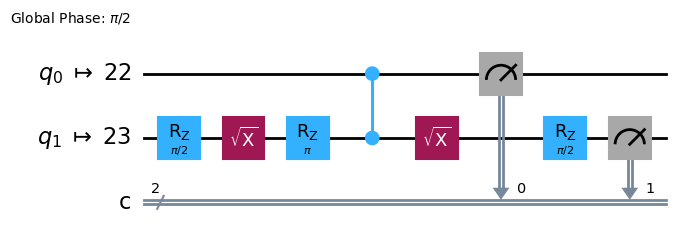

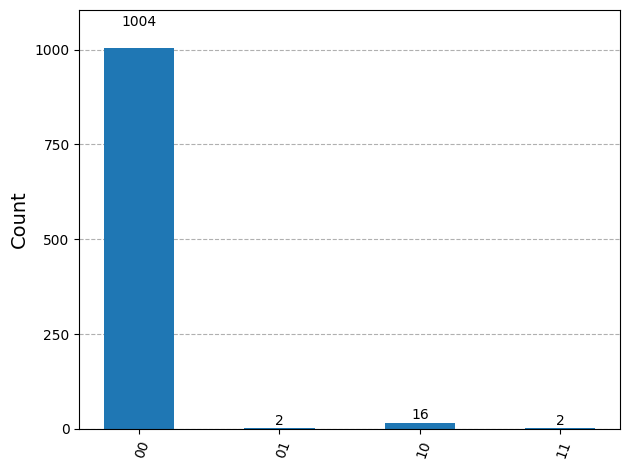

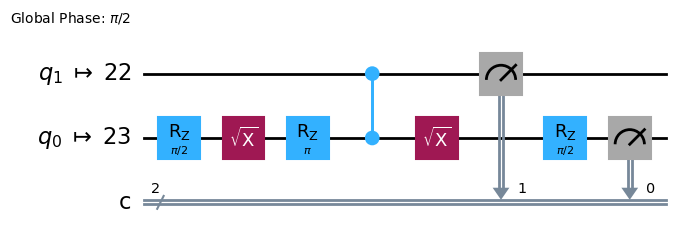

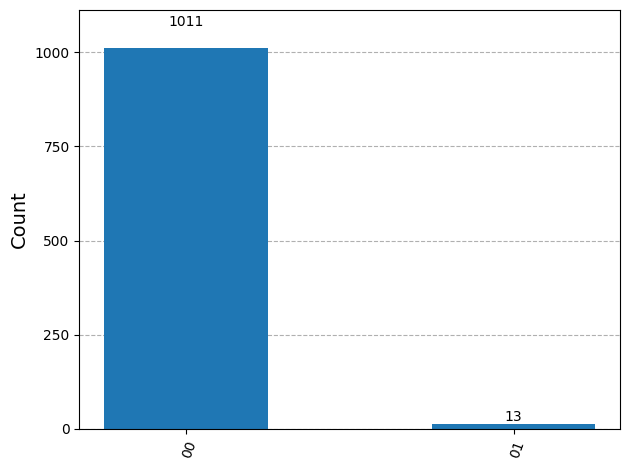

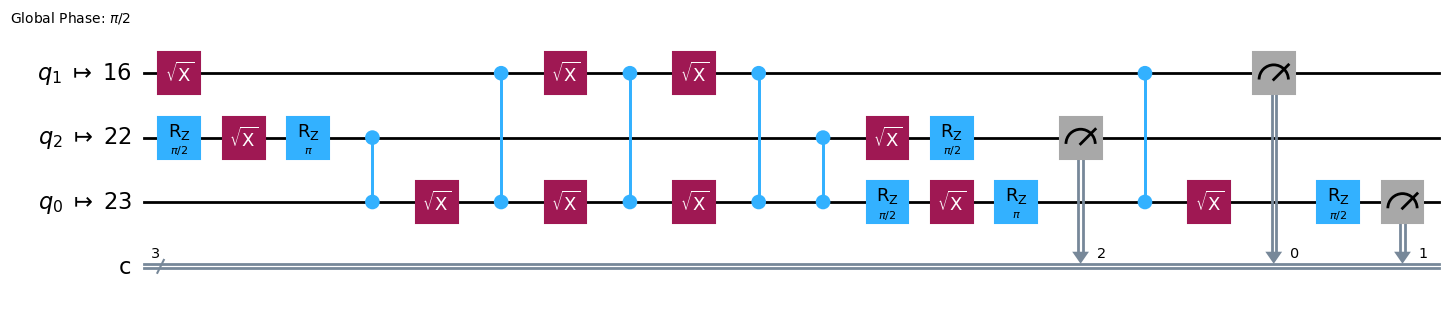

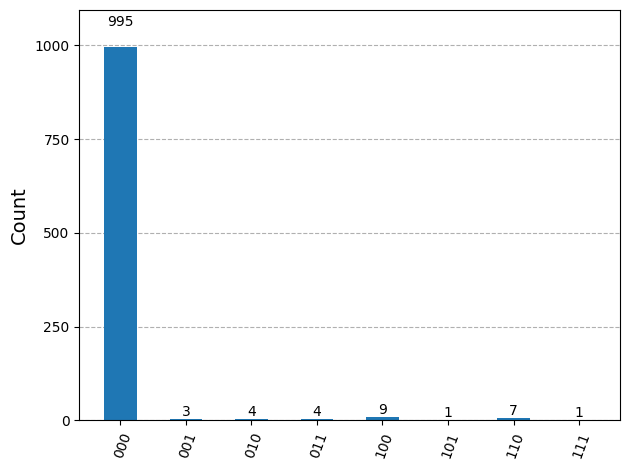

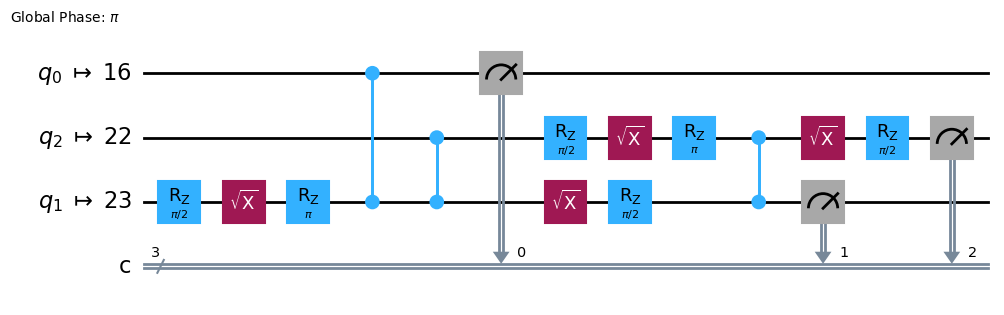

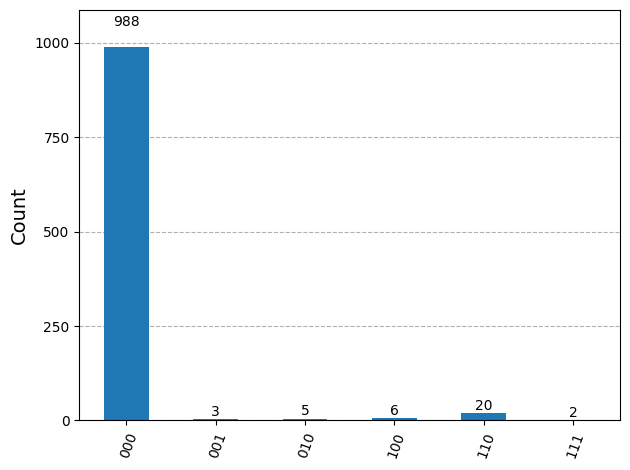

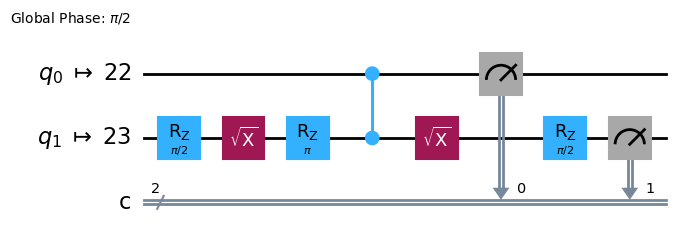

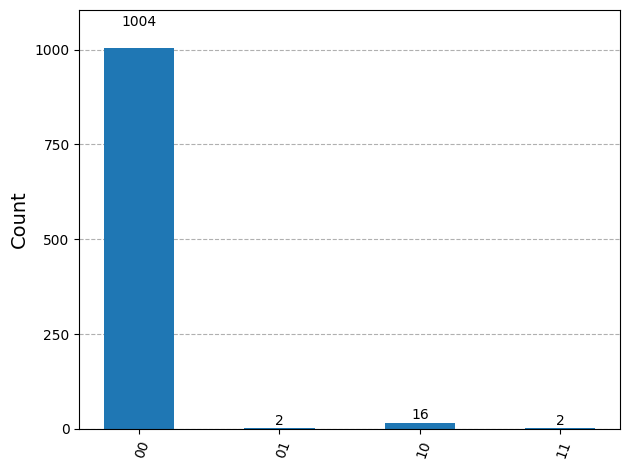

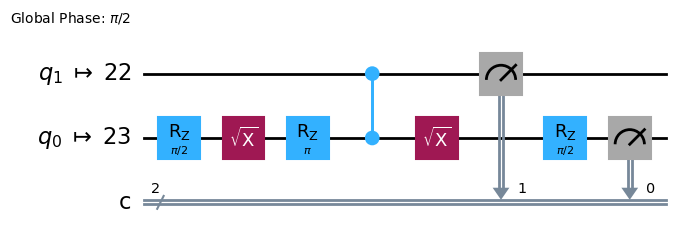

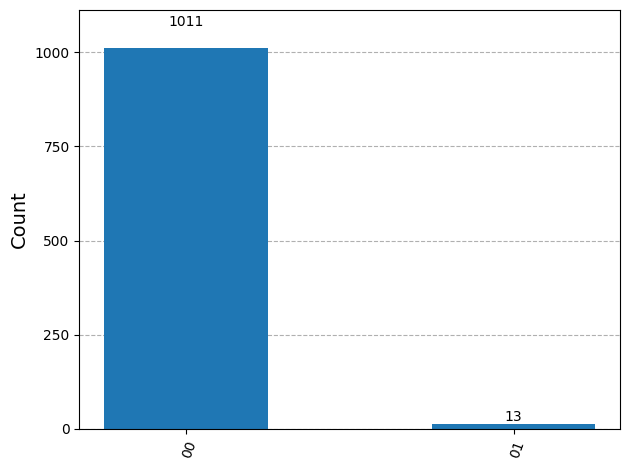

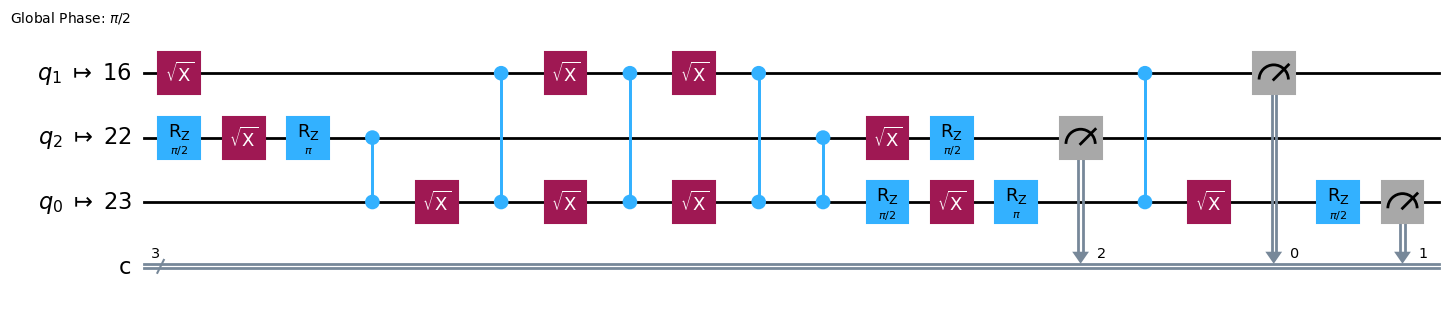

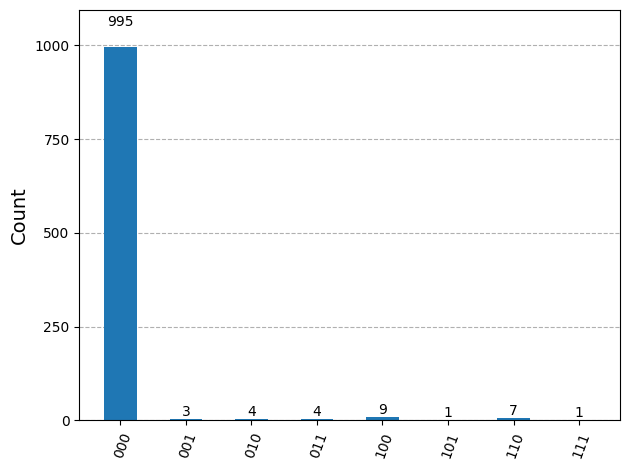

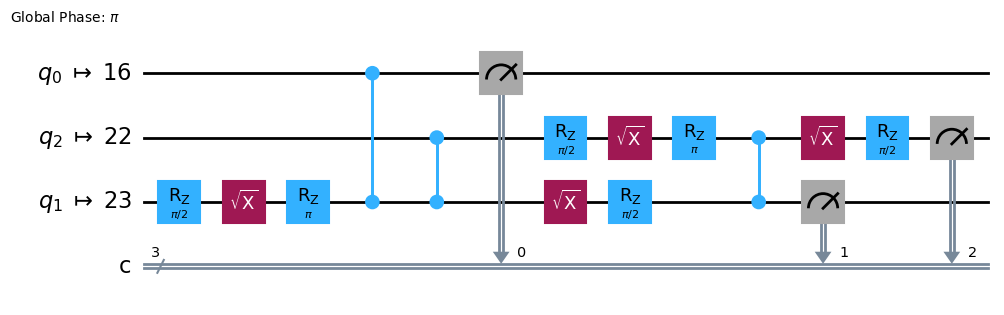

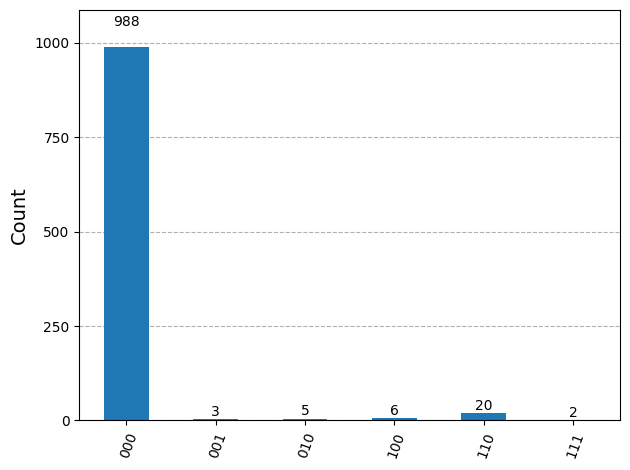

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler # type: ignore
from IPython.display import display

QiskitRuntimeService.save_account(
    channel="ibm_cloud",
    token="pfRijRvYkYgqEGZZFROec4xuQiGygG7mkA0oJM1VsqcU",
    overwrite=True,
)

service = QiskitRuntimeService(channel="ibm_cloud")
backend = service.least_busy(simulator=False, operational=True)

sampler = Sampler(backend)


def run(qc):
    qc = transpile(qc, backend)
    display(qc.draw("mpl"))
    job = sampler.run([qc], shots=1024)
    counts = job.result()[0].data.c.get_counts()
    display(plot_histogram(counts))


qc_a = QuantumCircuit(2, 2)
qc_a.h(1)
qc_a.cz(0, 1)
qc_a.h(1)
qc_a.measure([0, 1], [0, 1])
run(qc_a)

qc_b = QuantumCircuit(2, 2)
qc_b.h(0)
qc_b.h(1)
qc_b.cx(0, 1)
qc_b.h(0)
qc_b.h(1)
qc_b.measure([0, 1], [0, 1])
run(qc_b)

qc_c = QuantumCircuit(3, 3)
qc_c.cx(0, 2)
qc_c.cx(1, 2)
qc_c.cx(0, 1)
qc_c.measure([0, 1, 2], [0, 1, 2])
run(qc_c)

qc_d = QuantumCircuit(3, 3)
qc_d.cx(0, 1)
qc_d.cx(2, 1)
qc_d.cx(1, 2)
qc_d.measure([0, 1, 2], [0, 1, 2])
run(qc_d)